# DETEKSI EMOSI PADA TWEET BERBAHASA INDONESIA BERBASIS SVM

### Import Library

In [8]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Extract Dataset

In [9]:
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Tugas Kelompok/dataset/Twitter_Emotion_Dataset.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4401 entries, 0 to 4400
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   4401 non-null   object
 1   tweet   4401 non-null   object
dtypes: object(2)
memory usage: 68.9+ KB


In [11]:
df.groupby('label').count()

,tweet
label,
anger,1101
fear,649
happy,1017
love,637
sadness,997


### Preprocessing Text

In [12]:
# extract dictionary word of slang
DictSlang_df = pd.read_csv("/content/drive/MyDrive/Tugas Kelompok/dataset/kamus_singkatan.csv", sep=";")
DictSlang_df.head()

,singkatan,formal
0,aamiin,amin
1,adek,adik
2,adlh,adalah
3,aer,air
4,aiskrim,es krim


In [13]:
normalization_dict = dict(
    zip(
        DictSlang_df["singkatan"],
        DictSlang_df["formal"]
    )
)

In [14]:
nltk.download('stopwords')
stop_words = set(stopwords.words("indonesian"))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Case Folding
def case_folding(text):

    return text.lower()

# Data Cleaning
def cleaning(text):

    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Tokenization
def tokenizing(text):

    return text.split()

# Normalization
def normalize(tokens, normalization_dict):

    return [
        normalization_dict.get(word, word)
        for word in tokens
    ]

# Stopword Removal
def remove_stopwords(tokens):

    return [
        word
        for word in tokens
        if word not in stop_words
    ]

# Stemming
def stemming(tokens):

    text = " ".join(tokens)

    stemmed_text = stemmer.stem(text)

    return stemmed_text.split()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
# Run each function
df["case_folded_tweet"] = df["tweet"].apply(case_folding)
df["cleaned_tweet"] = df["case_folded_tweet"].apply(cleaning)
df["tokenized_tweet"] = df["cleaned_tweet"].apply(tokenizing)
df["normalized_tweet"] = df["tokenized_tweet"].apply(lambda x: normalize(x, normalization_dict))
df["stopwords_removed_tweet"] = df["normalized_tweet"].apply(remove_stopwords)
df["stemmed_tweet"] = df["stopwords_removed_tweet"].apply(stemming)

In [ ]:
# save result of preprocessing text
df.to_csv('result_preprocessing_tweet.csv', index=False)
df

,label,tweet,case_folded_tweet,cleaned_tweet,tokenized_tweet,normalized_tweet,stopwords_removed_tweet,stemmed_tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...","soal jln jatibaru,polisi tdk bs gertak gubernu...",soal jln jatibaru polisi tdk bs gertak gubernu...,"[soal, jln, jatibaru, polisi, tdk, bs, gertak,...","[soal, jalan , jatibaru, polisi, tidak, bisa, ...","[jalan , jatibaru, polisi, gertak, gubernur, e...","[jalan, jatibaru, polisi, gertak, gubernur, em..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi...","sesama cewe lho (kayaknya), harusnya bisa lebi...",sesama cewe lho kayaknya harusnya bisa lebih r...,"[sesama, cewe, lho, kayaknya, harusnya, bisa, ...","[sesama, cewek , lho, kayaknya, harusnya, bisa...","[cewek , lho, kayaknya, rasain, sibuk, jaga, r...","[cewek, lho, kayak, rasain, sibuk, jaga, rasai..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj. amad foto dari go...,kepingin gudeg mbarek bu hj amad foto dari goo...,"[kepingin, gudeg, mbarek, bu, hj, amad, foto, ...","[kepingin, gudeg, mbarek, bu, hj, amad, foto, ...","[kepingin, gudeg, mbarek, bu, hj, amad, foto, ...","[kepingin, gudeg, mbarek, bu, hj, amad, foto, ..."
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...","jln jatibaru,bagian dari wilayah tn abang.peng...",jln jatibaru bagian dari wilayah tn abang peng...,"[jln, jatibaru, bagian, dari, wilayah, tn, aba...","[jalan , jatibaru, bagian, dari, wilayah, tn, ...","[jalan , jatibaru, wilayah, tn, abang, pengatu...","[jalan, jatibaru, wilayah, tn, abang, atur, wi..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata...","sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman aja kemarin jam batalin tik...,"[sharing, pengalaman, aja, kemarin, jam, batal...","[sharing, pengalaman, saja , kemarin, jam, bat...","[sharing, pengalaman, saja , kemarin, jam, bat...","[sharing, alam, saja, kemarin, jam, batalin, t..."
...,...,...,...,...,...,...,...,...
4396,love,"Tahukah kamu, bahwa saat itu papa memejamkan m...","tahukah kamu, bahwa saat itu papa memejamkan m...",tahukah kamu bahwa saat itu papa memejamkan ma...,"[tahukah, kamu, bahwa, saat, itu, papa, memeja...","[tahukah, kamu, bahwa, saat, itu, papa, memeja...","[tahukah, papa, memejamkan, matanya, menahan, ...","[tahu, papa, mejam, mata, tahan, gejolak, bati..."
4397,fear,Sulitnya menetapkan Calon Wapresnya Jokowi di ...,sulitnya menetapkan calon wapresnya jokowi di ...,sulitnya menetapkan calon wapresnya jokowi di ...,"[sulitnya, menetapkan, calon, wapresnya, jokow...","[sulitnya, menetapkan, calon, wapresnya, jokow...","[sulitnya, menetapkan, calon, wapresnya, jokow...","[sulit, tetap, calon, wapresnya, jokowi, pilpr..."
4398,anger,"5. masa depannya nggak jelas. lha iya, gimana ...","5. masa depannya nggak jelas. lha iya, gimana ...",masa depannya nggak jelas lha iya gimana mau j...,"[masa, depannya, nggak, jelas, lha, iya, giman...","[masa, depannya, tidak, jelas, lha, iya, giman...","[depannya, lha, iya, gimana, coba, lulusan, se...","[depan, lha, iya, gimana, coba, lulus, seni, b..."
4399,happy,[USERNAME] dulu beneran ada mahasiswa Teknik U...,[username] dulu beneran ada mahasiswa teknik u...,username dulu beneran ada mahasiswa teknik ui ...,"[username, dulu, beneran, ada, mahasiswa, tekn...","[username, dulu, benar , ada, mahasiswa, tekni...","[username, benar , mahasiswa, teknik, ui, nemb...","[username, benar, mahasiswa, teknik, ui, nemba..."


### Splitting Data

In [16]:
tweets = df['stemmed_tweet']
labels = df['label']

## Splitting Data 80:10:10
# Pembagian data 80% data latih dan 20% data sisa
tweet_train, tweet_sisa, label_train, label_sisa = train_test_split(
    tweets,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels # digunakan agar jumlah data yang dibagi pada setiap label sama
)

tweet_val, tweet_test, label_val, label_test = train_test_split(
    tweet_sisa,
    label_sisa,
    test_size=0.5,
    random_state=42,
    stratify=label_sisa
)

print("Jumlah data train:", len(tweet_train))
print("Jumlah data validation :", len(tweet_val))
print("Jumlah data test :", len(tweet_test))

Jumlah data train: 3520
Jumlah data validation : 440
Jumlah data test : 441


In [17]:
print("Jumlah data latih per label:")
display(label_train.value_counts())

Jumlah data latih per label:


,count
label,
anger,881
happy,813
sadness,797
fear,519
love,510


In [18]:
# Encode labels
le = LabelEncoder()
label_train_encoded = le.fit_transform(label_train)
label_val_encoded = le.transform(label_val)
label_test_encoded = le.transform(label_test)

In [19]:
# Menampilkan nilai numerik pada setiap label
print("Mapping Label ke Numerik:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

Mapping Label ke Numerik:
anger: 0
fear: 1
happy: 2
love: 3
sadness: 4


### Features Extraxtion Using TF-IDF

In [20]:
tfidf_vectorizer = TfidfVectorizer()

tweet_train_tfidf = tfidf_vectorizer.fit_transform(tweet_train.apply(lambda x: ' '.join(x)))
tweet_val_tfidf = tfidf_vectorizer.transform(tweet_val.apply(lambda x: ' '.join(x)))
tweet_test_tfidf = tfidf_vectorizer.transform(tweet_test.apply(lambda x: ' '.join(x)))

print("Shape TF-IDF data latih:", tweet_train_tfidf.shape)
print("Shape TF-IDF data validasi:", tweet_val_tfidf.shape)
print("Shape TF-IDF data uji:", tweet_test_tfidf.shape)

Shape TF-IDF data latih: (3520, 11547)
Shape TF-IDF data validasi: (440, 11547)
Shape TF-IDF data uji: (441, 11547)


Ukuran Data Latih : 3520 baris (jumlah data latih), 11547 kolom (terdapat 11547 kosakata) <br>
Ukuran Data Validasi : 440 baris, 11547 kolom <br>
Ukuran Data Uji : 441 baris, 11547 kolom

In [21]:
tfidf_train_df = pd.DataFrame(
    tweet_train_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("5 baris pertama dari TF-IDF data latih:")
display(tfidf_train_df.head())

5 baris pertama dari TF-IDF data latih:


,aa,aaa,aaaaaa,aaaaaaa,aaaaaaaaa,aaaaak,aaaahhh,aaah,aaahhhh,aaamiiinnn,...,zidanelhadadi,zina,zmn,zohri,zon,zona,zonasi,zone,zonk,zulkifli
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Resampling

#### Skenario 1 Resampling : SMOTE

In [22]:
smote = SMOTE(random_state=42)
tweet_train_smote, label_train_smote = smote.fit_resample(tweet_train_tfidf, label_train_encoded)

print("Shape data latih setelah SMOTE:", tweet_train_smote.shape)
print("Jumlah label latih setelah SMOTE:")
print(Counter(label_train_smote))

Shape data latih setelah SMOTE: (4405, 11547)
Jumlah label latih setelah SMOTE:
Counter({np.int64(4): 881, np.int64(3): 881, np.int64(2): 881, np.int64(1): 881, np.int64(0): 881})


#### Skenario 2 Resampling : Random Undersampling

In [23]:
rus = RandomUnderSampler(random_state=42)
tweet_train_rus, label_train_rus = rus.fit_resample(tweet_train_tfidf, label_train_encoded)

print("Shape data latih setelah Random Undersampling:", tweet_train_rus.shape)
print("Jumlah label latih setelah Random Undersampling:")
print(Counter(label_train_rus))

Shape data latih setelah Random Undersampling: (2550, 11547)
Jumlah label latih setelah Random Undersampling:
Counter({np.int64(0): 510, np.int64(1): 510, np.int64(2): 510, np.int64(3): 510, np.int64(4): 510})


### Modeling

#### Baseline Model

##### Skenario 1 : SVM + SMOTE

In [24]:
# Inisialisasi model SVM dengan konfigurasi default
svm_model = SVC(random_state=42)

# Latih model menggunakan data latih yang sudah di-SMOTE
svm_model.fit(tweet_train_smote, label_train_smote)

# Prediksi pada data validasi
label_pred_val_smote = svm_model.predict(tweet_val_tfidf)

# Evaluasi performa model pada data validasi
accuracy_val_smote = accuracy_score(label_val_encoded, label_pred_val_smote)
precision_val_smote = precision_score(label_val_encoded, label_pred_val_smote, average='macro')
recall_val_smote = recall_score(label_val_encoded, label_pred_val_smote, average='macro')
f1_val_smote = f1_score(label_val_encoded, label_pred_val_smote, average='macro')

print("Performa Model SVM + SMOTE pada Data Validasi:")
print(f"Akurasi: {accuracy_val_smote:.4f}")
print(f"Presisi: {precision_val_smote:.4f}")
print(f"Recall: {recall_val_smote:.4f}")
print(f"F1-Score: {f1_val_smote:.4f}")

print("\nLaporan Klasifikasi Detail:")
target_labels = [str(cls) for cls in le.classes_]
print(classification_report(label_val_encoded, label_pred_val_smote, target_names=target_labels, zero_division=0))

Performa Model SVM + SMOTE pada Data Validasi:
Akurasi: 0.6591
Presisi: 0.7040
Recall: 0.6594
F1-Score: 0.6759

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

       anger       0.64      0.75      0.69       110
        fear       0.84      0.65      0.73        65
       happy       0.66      0.65      0.65       102
        love       0.88      0.70      0.78        63
     sadness       0.50      0.56      0.53       100

    accuracy                           0.66       440
   macro avg       0.70      0.66      0.68       440
weighted avg       0.68      0.66      0.66       440



##### Skenario 2 : SVM + Random Undersampling

In [25]:
# Inisialisasi model SVM dengan konfigurasi default
svm_model = SVC(random_state=42)

# Latih model menggunakan data latih yang sudah di-SMOTE
svm_model.fit(tweet_train_rus, label_train_rus)

# Prediksi pada data validasi
label_pred_val_rus = svm_model.predict(tweet_val_tfidf)

# Evaluasi performa model pada data validasi
accuracy_val_rus = accuracy_score(label_val_encoded, label_pred_val_rus)
precision_val_rus = precision_score(label_val_encoded, label_pred_val_rus, average='macro')
recall_val_rus = recall_score(label_val_encoded, label_pred_val_rus, average='macro')
f1_val_rus = f1_score(label_val_encoded, label_pred_val_rus, average='macro')

print("Performa Model SVM + RUS pada Data Validasi:")
print(f"Akurasi: {accuracy_val_rus:.4f}")
print(f"Presisi: {precision_val_rus:.4f}")
print(f"Recall: {recall_val_rus:.4f}")
print(f"F1-Score: {f1_val_rus:.4f}")

print("\nLaporan Klasifikasi Detail:")
target_labels = [str(cls) for cls in le.classes_]
print(classification_report(label_val_encoded, label_pred_val_rus, target_names=target_labels, zero_division=0))

Performa Model SVM + RUS pada Data Validasi:
Akurasi: 0.6318
Presisi: 0.6711
Recall: 0.6456
F1-Score: 0.6560

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

       anger       0.61      0.59      0.60       110
        fear       0.75      0.66      0.70        65
       happy       0.64      0.61      0.62       102
        love       0.88      0.78      0.82        63
     sadness       0.48      0.59      0.53       100

    accuracy                           0.63       440
   macro avg       0.67      0.65      0.66       440
weighted avg       0.65      0.63      0.64       440



#### Best Model Hyperparameter Tuning

Dari hasil baseline model sebelumnya, didapatkan model SVM + SMOTE lebih unggul dengan akurasi sebesar 65% dan f1-score sebesar 67%. <br>

Selanjutnya dilakukan tuning untuk model SVM + SMOTE

Parameter yang di tuning meliputi: <br>
1. Jenis Kernel : linear kernel, polynomial kernel, dan Radial Basis Function (RBF).
2. Nilai C : 0.1, 1, 10, dan 100

In [26]:
# Inisialisasi tweet train dan label train dari baseline terbaik (SMOTE)
tweet_tuning = tweet_train_smote
label_tuning = label_train_smote

# Inisialisasi parameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf'],
    'gamma': ['scale', 'auto'],
    'degree': [3]
}

# Inisialisasi metode Grid Search dengan Cross-Validation
grid_search = GridSearchCV(
    estimator=SVC(random_state=42, probability=True),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1
)

# Pencarian parameter
grid_search.fit(tweet_tuning, label_tuning)

# Menampilkan semua output dari setiap kombinasi
print("HASIL PENCARIAN SETIAP KOMBINASI PARAMETER:")

# Mengubah hasil cv_results_ menjadi DataFrame Pandas
df_results = pd.DataFrame(grid_search.cv_results_)

# Mengambil kolom-kolom penting saja agar ringkas dan mudah dibaca
kolom_pilihan = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
df_results_filtered = df_results[kolom_pilihan].sort_values(by='rank_test_score')

# Menampilkan semua baris kombinasi
pd.set_option('display.max_colwidth', None)
for index, row in df_results_filtered.iterrows():
    print(f"Rank {row['rank_test_score']} -> Parameter: {row['params']}")
    print(f"        Rata-rata Macro F1 (CV): {row['mean_test_score'] * 100:.2f}% (+/- {row['std_test_score'] * 2 * 100:.2f}%)")
    print("-" * 70)

# Menampilkan hasil parameter terbaik dan performa pada data validasi
print("KESIMPULAN PARAMETER TERBAIK")
print(f"Kombinasi Parameter Terbaik : {grid_search.best_params_}")
print(f"Best Cross-Validation Score : {grid_search.best_score_ * 100:.2f}% (Macro F1)")

# Mengambil arsitektur model pemenang
best_model_svm = grid_search.best_estimator_

# Menguji ulang ke data validasi manual (10%) sebagai konfirmasi akhir
label_pred_val_tuned = best_model_svm.predict(tweet_val_tfidf)

print("\nPERFORMA MODEL TERBAIK PADA DATA VALIDASI (10%):")
print(f"Akurasi Keseluruhan      : {accuracy_score(label_val_encoded, label_pred_val_tuned) * 100:.2f}%")
print(f"Macro Average F1-Score   : {f1_score(label_val_encoded, label_pred_val_tuned, average='macro') * 100:.2f}%")
print("\nLaporan Klasifikasi Detail (Tuned Model):")

target_labels = [str(cls) for cls in le.classes_]
print(classification_report(label_val_encoded, label_pred_val_tuned, target_names=target_labels, zero_division=0))
print("="*70)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
HASIL PENCARIAN SETIAP KOMBINASI PARAMETER:
Rank 1 -> Parameter: {'C': 10, 'degree': 3, 'gamma': 'scale', 'kernel': 'linear'}
        Rata-rata Macro F1 (CV): 75.21% (+/- 9.96%)
----------------------------------------------------------------------
Rank 1 -> Parameter: {'C': 10, 'degree': 3, 'gamma': 'auto', 'kernel': 'linear'}
        Rata-rata Macro F1 (CV): 75.21% (+/- 9.96%)
----------------------------------------------------------------------
Rank 3 -> Parameter: {'C': 100, 'degree': 3, 'gamma': 'auto', 'kernel': 'linear'}
        Rata-rata Macro F1 (CV): 75.15% (+/- 9.80%)
----------------------------------------------------------------------
Rank 3 -> Parameter: {'C': 100, 'degree': 3, 'gamma': 'scale', 'kernel': 'linear'}
        Rata-rata Macro F1 (CV): 75.15% (+/- 9.80%)
----------------------------------------------------------------------
Rank 5 -> Parameter: {'C': 10, 'degree': 3, 'gamma': 'scale', 'kernel': 'r

Parameter terbaik adalah nilai C=10, degree=3, gamma=scale, dan kernel=linear dengan F1-Score sebesar 75,21%

### Testing Tuned Model

HASIL PERFORMA TESTING FINAL MODEL SVM
Akurasi: 0.5601
Presisi: 0.5926
Recall: 0.5719
F1-Score: 0.5796
------------------------------------------------------------
Laporan Klasifikasi Detail Akhir per Kelas:
              precision    recall  f1-score   support

       anger       0.57      0.69      0.62       110
        fear       0.75      0.65      0.69        65
       happy       0.51      0.46      0.48       102
        love       0.75      0.67      0.71        64
     sadness       0.39      0.39      0.39       100

    accuracy                           0.56       441
   macro avg       0.59      0.57      0.58       441
weighted avg       0.57      0.56      0.56       441



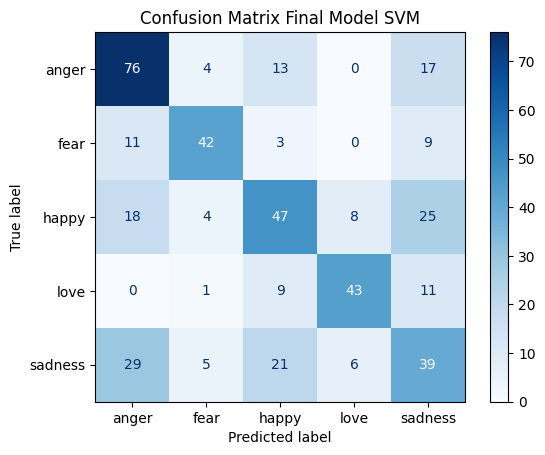

In [27]:
# testing using tuned model
label_pred_test = best_model_svm.predict(tweet_test_tfidf)

# Evaluasi performa model pada data uji
accuracy_test = accuracy_score(label_test_encoded, label_pred_test)
precision_test = precision_score(label_test_encoded, label_pred_test, average='macro')
recall_test = recall_score(label_test_encoded, label_pred_test, average='macro')
f1_test = f1_score(label_test_encoded, label_pred_test, average='macro')

print("HASIL PERFORMA TESTING FINAL MODEL SVM")
print(f"Akurasi: {accuracy_test:.4f}")
print(f"Presisi: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print("-" * 60)
print("Laporan Klasifikasi Detail Akhir per Kelas:")

# Menampilkan nama emosi asli berdasarkan objek LabelEncoder ('le') Anda
target_labels = [str(cls) for cls in le.classes_]
print(classification_report(label_test_encoded, label_pred_test, target_names=target_labels))
print("="*60)

# Visualisasi Confusion Matrix
cm = confusion_matrix(label_test_encoded, label_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix Final Model SVM')
plt.show()

In [ ]:
## INFERENCE MODEL

def predict_emotion(tweet_text):
    # Preprocessing the input tweet
    cleaned_tweet = cleaning(case_folding(tweet_text))
    tokenized_tweet = tokenizing(cleaned_tweet)
    normalized_tweet = normalize(tokenized_tweet, normalization_dict)
    stopwords_removed_tweet = remove_stopwords(normalized_tweet)
    stemmed_tweet = stemming(stopwords_removed_tweet)

    # Convert to TF-IDF features
    tweet_tfidf = tfidf_vectorizer.transform([' '.join(stemmed_tweet)])

    # Get prediction probabilities
    probabilities = best_model_svm.predict_proba(tweet_tfidf)[0]

    # Get the emotion with the highest probability and its confidence score
    predicted_emotion_index = np.argmax(probabilities)
    predicted_emotion_label = le.classes_[predicted_emotion_index]
    confidence_score = probabilities[predicted_emotion_index]

    print(f"Original Tweet: {tweet_text}")
    print(f"\nEmosi Diprediksi: {predicted_emotion_label}")
    print(f"Skor Kepercayaan: {confidence_score:.4f}")

# Contoh penggunaan:
# Meminta input tweet dari pengguna secara dinamis
user_tweet = input("Masukkan tweet Anda: ")
predict_emotion(user_tweet)

Masukkan tweet Anda: sumpah rumah hantunya seram banget, aku gamau lagi kesana
Original Tweet: sumpah rumah hantunya seram banget, aku gamau lagi kesana

Emosi Diprediksi: fear
Skor Kepercayaan: 0.9990


# Saved File

In [ ]:
# save best tuned model
joblib.dump(best_model_svm, 'best_model_svm.pkl')

# save TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

# save Label Encoder
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']